# 5.1 Convolution operation

Output for filter 1:
tensor([[-1.,  0.,  2.],
        [-2., -1.,  1.],
        [ 1.,  1., -1.]])

Output for filter 2:
tensor([[ 3., -1., -2.],
        [ 2.,  1.,  0.],
        [ 2.,  2.,  0.]])

Output for filter 3:
tensor([[ 2.,  1., -2.],
        [-2.,  2.,  1.],
        [-1., -3.,  1.]])



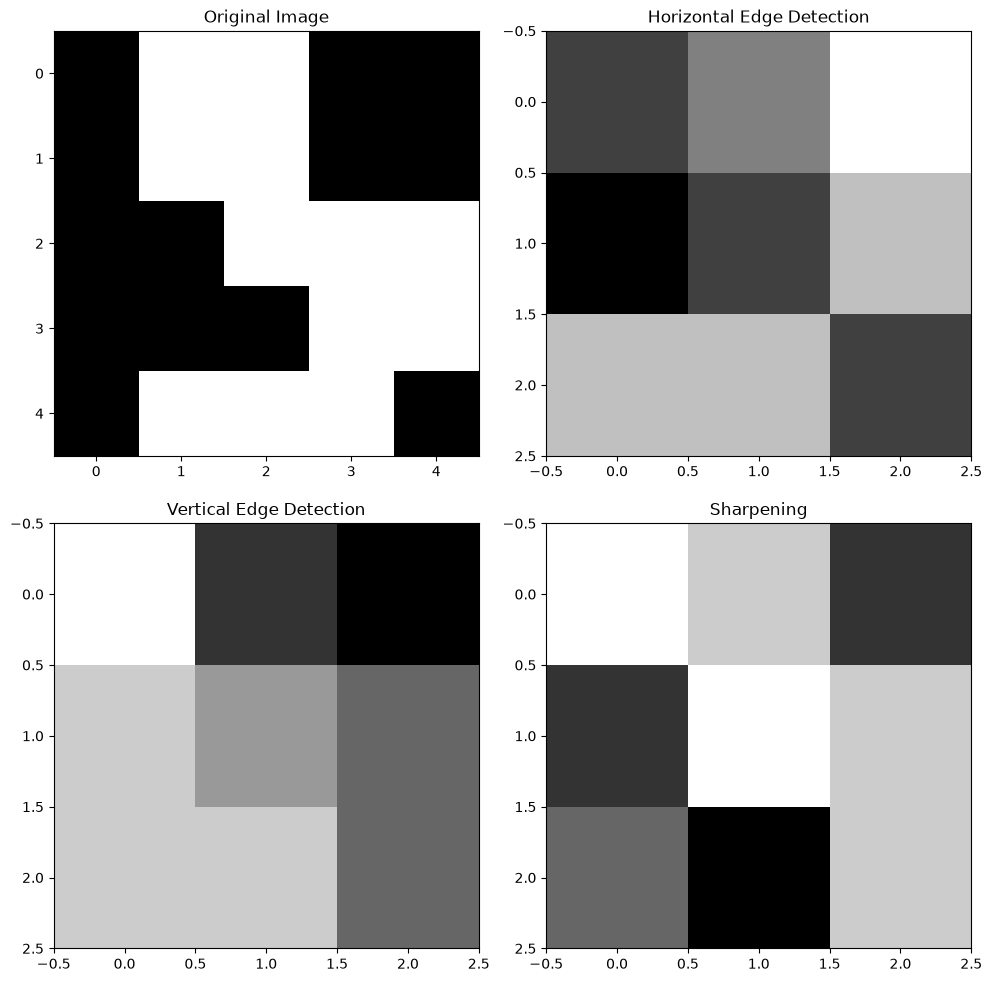

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Define a 5x5 image (grayscale) as a PyTorch tensor
image = (
    torch.tensor(
        [
            [0, 1, 1, 0, 0],
            [0, 1, 1, 0, 0],
            [0, 0, 1, 1, 1],
            [0, 0, 0, 1, 1],
            [0, 1, 1, 1, 0],
        ],
        dtype=torch.float32,
    )
    .unsqueeze(0)
    .unsqueeze(0)
)

# Define multiple 3x3 filters
filters = torch.tensor(
    [
        [[-1, -1, -1], [0, 0, 0], [1, 1, 1]],  # Horizontal edge detector
        [[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]],  # Vertical edge detector
        [[0, -1, 0], [-1, 4, -1], [0, -1, 0]],  # Sharpening filter
    ],
    dtype=torch.float32,
).unsqueeze(1)

# Apply convolution operations
outputs = []
for i, filter in enumerate(filters):
    output = F.conv2d(image, filter.unsqueeze(0))
    outputs.append(output.squeeze().detach().numpy())
    print(f"Output for filter {i+1}:")
    print(output.squeeze())
    print()

# Visualize the results
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs[0, 0].imshow(image.squeeze(), cmap='gray')
axs[0, 0].set_title('Original Image')
axs[0, 1].imshow(outputs[0], cmap='gray')
axs[0, 1].set_title('Horizontal Edge Detection')
axs[1, 0].imshow(outputs[1], cmap='gray')
axs[1, 0].set_title('Vertical Edge Detection')
axs[1, 1].imshow(outputs[2], cmap='gray')
axs[1, 1].set_title('Sharpening')
plt.tight_layout()
plt.show()

# 5.2 Pooling layer (max pooling operation)

Original Feature Map:
tensor([[1., 3., 2., 4.],
        [5., 6., 7., 8.],
        [3., 2., 1., 0.],
        [9., 5., 4., 2.]])
Pooled Output:
tensor([[6., 8.],
        [9., 4.]])


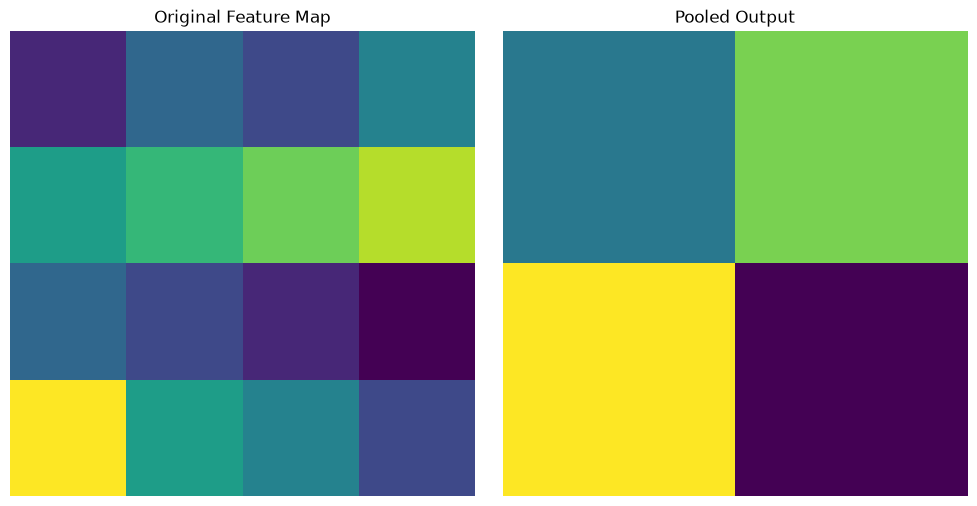

Pooled Output (stride=2):
tensor([[6., 8.],
        [9., 4.]])
Pooled Output (stride=1):
tensor([[6., 7., 8.],
        [6., 7., 8.],
        [9., 5., 4.]])


In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Define a 4x4 feature map
feature_map = (
    torch.tensor(
        [[1, 3, 2, 4], [5, 6, 7, 8], [3, 2, 1, 0], [9, 5, 4, 2]], dtype=torch.float32
    )
    .unsqueeze(0)
    .unsqueeze(0)
)
# Apply max pooling with a 2x2 kernel
pooled_output = F.max_pool2d(feature_map, kernel_size=2)
# Print the original feature map and pooled output
print("Original Feature Map:")
print(feature_map.squeeze())
print("Pooled Output:")
print(pooled_output.squeeze())
# Visualize the feature map and pooled output
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(feature_map.squeeze(), cmap="viridis")
ax1.set_title("Original Feature Map")
ax1.axis("off")
ax2.imshow(pooled_output.squeeze(), cmap="viridis")
ax2.set_title("Pooled Output")
ax2.axis("off")
plt.tight_layout()
plt.show()
# Demonstrate the effect of stride
stride_2_output = F.max_pool2d(feature_map, kernel_size=2, stride=2)
stride_1_output = F.max_pool2d(feature_map, kernel_size=2, stride=1)
print("Pooled Output (stride=2):")
print(stride_2_output.squeeze())
print("Pooled Output (stride=1):")
print(stride_1_output.squeeze())

# 5.3 ReLU activation function

In [7]:
import torch.nn.functional as F

# Define a sample feature map with both positive and negative values
feature_map = torch.tensor([[-1, 2, -3], [4, -5, 6], [-7, 8, -9]], dtype=torch.float32)

# Apply ReLU activation
relu_output = F.relu(feature_map)

# Print the output after applying ReLU
print(relu_output)

tensor([[0., 2., 0.],
        [4., 0., 6.],
        [0., 8., 0.]])


# 5.4 Training a CNN on the MNIST dataset

Epoch [1/5], Loss: 0.1679, Accuracy: 94.64%
Epoch [2/5], Loss: 0.0448, Accuracy: 98.63%
Epoch [3/5], Loss: 0.0306, Accuracy: 99.05%
Epoch [4/5], Loss: 0.0216, Accuracy: 99.33%
Epoch [5/5], Loss: 0.0174, Accuracy: 99.44%
Test Accuracy: 99.04%


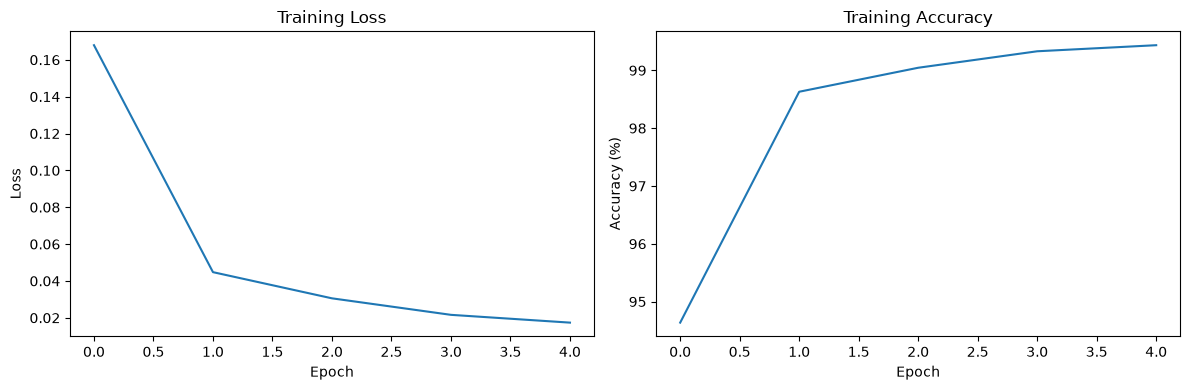

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Define a simple CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 5 * 5)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the MNIST dataset
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
)
train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define model, loss function and optimizer
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# Train the CNN
num_epochs = 5
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')
    
# Evaluate the model
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")
# Plot training loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.subplot(1, 2, 2)
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.tight_layout()
plt.show()

# 5.5 CNN in TensorFlow

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9037 - loss: 0.3152 - val_accuracy: 0.9830 - val_loss: 0.0548
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9718 - loss: 0.1001 - val_accuracy: 0.9878 - val_loss: 0.0373
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9795 - loss: 0.0713 - val_accuracy: 0.9902 - val_loss: 0.0304
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9845 - loss: 0.0533 - val_accuracy: 0.9917 - val_loss: 0.0278
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9869 - loss: 0.0461 - val_accuracy: 0.9923 - val_loss: 0.0266
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9890 - loss: 0.0397 - val_accuracy: 0.9917 - val_loss: 0.0286
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9900 - loss: 0.0337 - val_accuracy: 0.9904 - val_loss: 0.0388
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9913 - loss: 0.0317 - val_accuracy: 0.

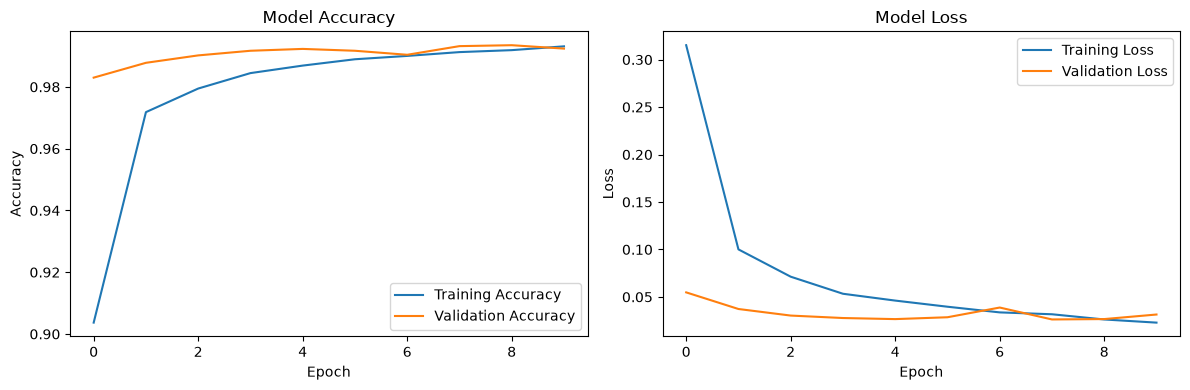

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


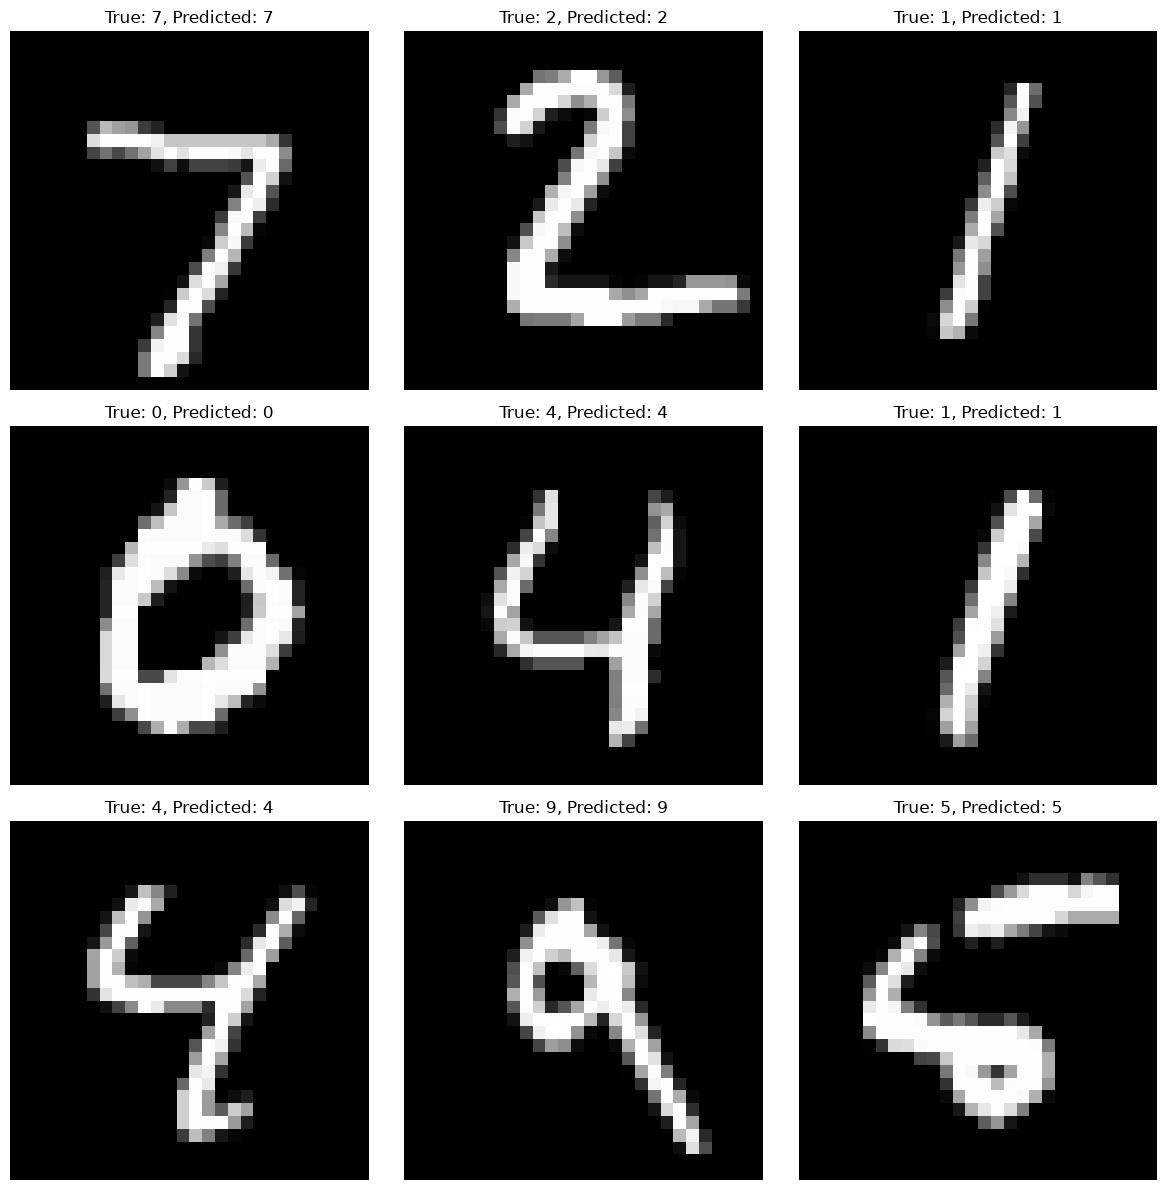

In [4]:
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Preprocess the data (reshape and normalize)
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0


# Define the CNN model
class SimpleCNN(keras.Model):
    def __init__(self, num_classes=10, **kwargs):
        super().__init__(**kwargs)
        self.conv1 = layers.Conv2D(32, 3, activation="relu")
        self.pool1 = layers.MaxPooling2D()
        self.conv2 = layers.Conv2D(64, 3, activation="relu")
        self.pool2 = layers.MaxPooling2D()
        self.conv3 = layers.Conv2D(64, 3, activation="relu")
        self.flatten = layers.Flatten()
        self.fc1 = layers.Dense(64, activation="relu")
        self.dropout = layers.Dropout(0.5)
        self.fc2 = layers.Dense(num_classes, activation="softmax")

    def call(self, x, training=False):
        x = self.pool1(self.conv1(x))
        x = self.pool2(self.conv2(x))
        x = self.flatten(self.conv3(x))
        x = self.dropout(self.fc1(x), training=training)
        return self.fc2(x)


# Instantiate the model
model = SimpleCNN()

# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
)

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Test Accuracy: {test_acc:.4f}")

# Plot training history
fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in [
    (ax_acc, "accuracy", "Model Accuracy"),
    (ax_loss, "loss", "Model Loss"),
]:
    ax.plot(history.history[metric], label=f"Training {metric.capitalize()}")
    ax.plot(history.history[f"val_{metric}"], label=f"Validation {metric.capitalize()}")
    ax.set(title=title, xlabel="Epoch", ylabel=metric.capitalize())
    ax.legend()
plt.tight_layout()
plt.show()

# Make predictions on test data
predictions = model.predict(X_test)

# Display some test images and their predictions
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].squeeze(), cmap="gray")
    ax.set_title(f"True: {y_test[i]}, Predicted: {predictions[i].argmax()}")
    ax.axis("off")

plt.tight_layout()
plt.show()